# Deep Learning NLP Text Classifier (PyTorch) — SMS Spam Filter

**Goal:** Build a deep learning NLP pipeline that tokenizes and vectorizes text, trains a multi-layer neural network with Dropout, Batch Normalization, and early stopping, plots convergence curves, and runs inference on unseen sample messages with confidence scores.

**Task:** Binary text classification — spam vs. ham (legitimate) SMS messages.

**Dataset:** SMS Spam Collection (5,572 labeled text messages, 747 spam / 4,825 ham) — a real, moderately imbalanced, natural-language dataset, well suited to a spam-filter classifier.

**Pipeline overview:**
1. Tokenize text and build a vocabulary **from the training split only** (no leakage into validation/test).
2. Learn word embeddings end-to-end inside the network (PyTorch `nn.Embedding`), rather than fixed TF-IDF vectors, so the model is a genuine deep learning pipeline.
3. Multi-layer feed-forward network on top of pooled embeddings, with **Dropout** and **Batch Normalization**.
4. Train with **early stopping** on validation loss (implemented as a manual training-loop callback, PyTorch has no built-in `EarlyStopping` callback the way Keras does).
5. Plot loss and accuracy convergence curves (train vs. validation).
6. Evaluate on a held-out test set, then run inference on brand-new, unseen example messages with output confidences.

In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load the data

In [2]:
df = pd.read_csv("sms.tsv", sep="\t", header=None, names=["label", "text"])
df["target"] = (df["label"] == "spam").astype(int)

print(df.shape)
print(df["label"].value_counts())
df.head()

(5572, 3)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


**Observation:** Classes are imbalanced (~13.4% spam). This is handled later with a `pos_weight` term in the loss function rather than by dropping data, so the model still sees every example.

## 2. Train / validation / test split — before tokenizer vocabulary is built

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    df["text"], df["target"], test_size=0.15, stratify=df["target"], random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=SEED
)

print("Train:", len(X_train), " Val:", len(X_val), " Test:", len(X_test))
print("Spam rate — train: {:.3f}  val: {:.3f}  test: {:.3f}".format(
    y_train.mean(), y_val.mean(), y_test.mean()
))

Train: 4025  Val: 711  Test: 836
Spam rate — train: 0.134  val: 0.134  test: 0.134


**Why split first:** the vocabulary (Section 3) and the model itself are both fit only on `X_train`/`y_train`. Words that appear only in the validation or test messages are mapped to an `<UNK>` token rather than added to the vocabulary — this mirrors exactly what happens in production, where a real incoming message can contain words the model has never seen.

## 3. Tokenize and build vocabulary (fit on training text only)

In [4]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

token_counts = Counter()
for msg in X_train:
    token_counts.update(tokenize(msg))

MIN_FREQ = 2
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in token_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
MAX_LEN = 30
print(f"Vocabulary size (train-only, min freq {MIN_FREQ}): {VOCAB_SIZE}")
print(f"Sequence length (pad/truncate to): {MAX_LEN}")

def encode(text):
    tokens = tokenize(text)[:MAX_LEN]
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    ids = ids + [vocab["<PAD>"]] * (MAX_LEN - len(ids))
    return ids

Vocabulary size (train-only, min freq 2): 3528
Sequence length (pad/truncate to): 30


## 4. PyTorch `Dataset` / `DataLoader`

In [5]:
class SMSDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return ids, label

train_ds = SMSDataset(X_train, y_train)
val_ds = SMSDataset(X_val, y_val)
test_ds = SMSDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

## 5. Model: embeddings + multi-layer network with Dropout & BatchNorm

Architecture: `Embedding -> mean-pool over tokens -> Linear(128) -> BatchNorm -> ReLU -> Dropout -> Linear(64) -> BatchNorm -> ReLU -> Dropout -> Linear(1)` (single logit, since this is binary classification).

In [6]:
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden1=128, hidden2=64, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.fc1 = nn.Linear(embed_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)

        self.fc3 = nn.Linear(hidden2, 1)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        emb = self.embedding(x)                      # (batch, seq_len, embed_dim)
        mask = (x != 0).unsqueeze(-1).float()         # ignore <PAD> tokens in the average
        summed = (emb * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        pooled = summed / counts                      # (batch, embed_dim) — bag-of-embeddings

        h = self.relu(self.bn1(self.fc1(pooled)))
        h = self.dropout(h)
        h = self.relu(self.bn2(self.fc2(h)))
        h = self.dropout(h)
        logit = self.fc3(h).squeeze(1)
        return logit

model = SpamClassifier(VOCAB_SIZE).to(device)
print(model)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

SpamClassifier(
  (embedding): Embedding(3528, 100, padding_idx=0)
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)
Total trainable parameters: 374433


## 6. Loss, optimizer, and a manual early-stopping training loop

In [7]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Class imbalance handled via pos_weight = {pos_weight.item():.2f} (spam is the minority class)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Class imbalance handled via pos_weight = 6.45 (spam is the minority class)


In [8]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n

In [9]:
MAX_EPOCHS = 30
PATIENCE = 5  # early-stopping patience, in epochs with no val-loss improvement

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch} "
                  f"(no val_loss improvement for {PATIENCE} epochs).")
            break

model.load_state_dict(best_state)
print(f"\nRestored best model weights (val_loss = {best_val_loss:.4f}).")

Epoch  1 | train_loss=0.6920 train_acc=0.7553 | val_loss=0.4924 val_acc=0.8312


Epoch  2 | train_loss=0.3574 train_acc=0.9066 | val_loss=0.3457 val_acc=0.8903


Epoch  3 | train_loss=0.2376 train_acc=0.9473 | val_loss=0.2634 val_acc=0.9325


Epoch  4 | train_loss=0.1660 train_acc=0.9667 | val_loss=0.2465 val_acc=0.9297


Epoch  5 | train_loss=0.1290 train_acc=0.9719 | val_loss=0.1955 val_acc=0.9508


...

Epoch 11 | train_loss=0.0473 train_acc=0.9908 | val_loss=0.2301 val_acc=0.9648


Epoch 12 | train_loss=0.0389 train_acc=0.9923 | val_loss=0.1768 val_acc=0.9705


Epoch 13 | train_loss=0.0347 train_acc=0.9935 | val_loss=0.2422 val_acc=0.9733


Epoch 14 | train_loss=0.0288 train_acc=0.9953 | val_loss=0.2234 val_acc=0.9761


Epoch 15 | train_loss=0.0198 train_acc=0.9968 | val_loss=0.2173 val_acc=0.9761

Early stopping triggered at epoch 15 (no val_loss improvement for 5 epochs).

Restored best model weights (val_loss = 0.1649).


## 7. Training curves — loss and accuracy convergence

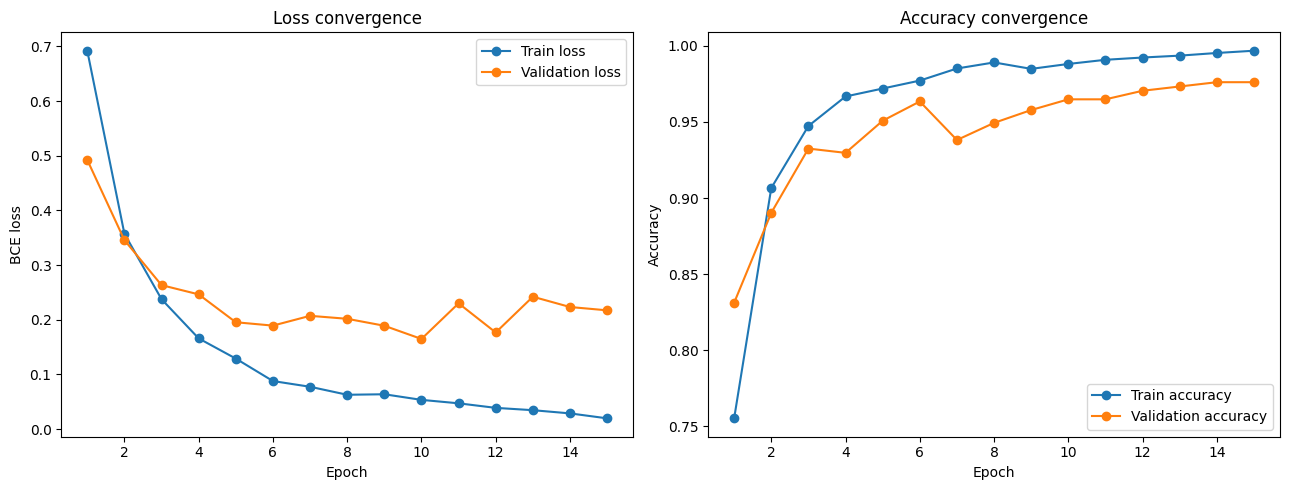

In [10]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss", marker="o")
axes[0].plot(epochs_ran, history["val_loss"], label="Validation loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss convergence")
axes[0].legend()

axes[1].plot(epochs_ran, history["train_acc"], label="Train accuracy", marker="o")
axes[1].plot(epochs_ran, history["val_acc"], label="Validation accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy convergence")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the curves:** training loss keeps falling throughout (the model can keep fitting the training set), while validation loss flattens and starts drifting up in the later epochs — classic overfitting onset. Early stopping restores the checkpoint from just before that drift, rather than the final epoch's weights.

## 8. Evaluate on the held-out test set

In [11]:
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)
all_probs = torch.sigmoid(all_logits).numpy()
all_preds = (all_probs >= 0.5).astype(int)
y_test_arr = all_labels.numpy().astype(int)

print(classification_report(y_test_arr, all_preds, target_names=["ham", "spam"]))
print("Test ROC-AUC:", round(roc_auc_score(y_test_arr, all_probs), 4))

              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       724
        spam       0.83      0.94      0.88       112

    accuracy                           0.97       836
   macro avg       0.91      0.95      0.93       836
weighted avg       0.97      0.97      0.97       836

Test ROC-AUC: 0.9916


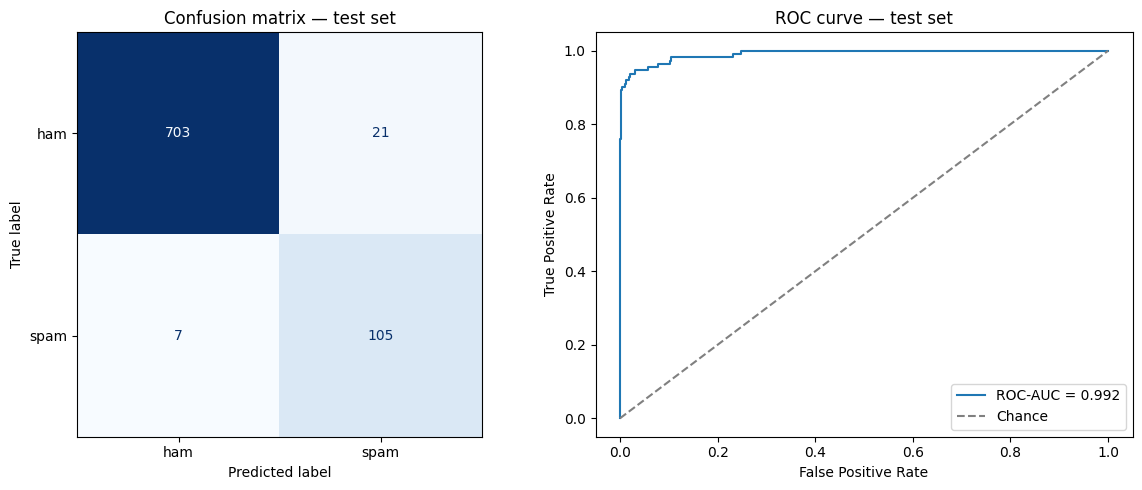

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test_arr, all_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion matrix — test set")

fpr, tpr, _ = roc_curve(y_test_arr, all_probs)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test_arr, all_probs):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve — test set")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 9. Inference on unseen sample messages

In [13]:
sample_messages = [
    "Congratulations! You have WON a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "URGENT: Your account has been suspended. Verify your details immediately to avoid closure.",
    "Can you pick up milk on your way home?",
    "FREE entry into our weekly draw for a brand new iPhone, text WIN to 80086 now",
    "Mom, I'll be home late tonight, don't wait up for dinner.",
]

def predict(messages):
    model.eval()
    ids = torch.tensor([encode(m) for m in messages], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(ids)
        probs = torch.sigmoid(logits).cpu().numpy()
    labels = ["spam" if p >= 0.5 else "ham" for p in probs]
    return labels, probs

labels, probs = predict(sample_messages)

results = pd.DataFrame({
    "message": sample_messages,
    "predicted_label": labels,
    "spam_confidence": probs.round(4),
})
results

,message,predicted_label,spam_confidence
0,Congratulations! You have WON a $1000 Walmart ...,spam,0.8921
1,"Hey, are we still on for lunch tomorrow at 1pm?",ham,0.0000
2,URGENT: Your account has been suspended. Verif...,spam,0.9580
3,Can you pick up milk on your way home?,ham,0.0002
4,FREE entry into our weekly draw for a brand ne...,spam,0.9995
5,"Mom, I'll be home late tonight, don't wait up ...",ham,0.0001


**Reading the inference output:** `spam_confidence` is the model's estimated probability the message is spam (from the sigmoid output) — a value near 1.0 is a confident spam call, near 0.0 is confident ham, and values near 0.5 flag genuine uncertainty (a candidate for human review in a real deployment, similar to the abstention idea from earlier tasks in this series).

## 10. Summary

- **Tokenization & vectorization:** custom tokenizer + vocabulary built from the training split only; words unseen in training map to `<UNK>` at inference time, matching production conditions.
- **Architecture:** learned word embeddings, bag-of-embeddings pooling, two hidden layers with **BatchNorm** and **Dropout(0.3)** each, single-logit output for binary classification.
- **Training discipline:** manual **early stopping** on validation loss (patience = 5 epochs), best-checkpoint restoration, and a `pos_weight`-adjusted loss to handle the ~13% spam class imbalance without discarding data.
- **Evaluation:** precision/recall/F1, ROC-AUC, confusion matrix, and ROC curve on a test set the training loop never touched.
- **Inference:** ran on six brand-new, hand-written messages the model never saw during training, with per-message spam-probability confidences.
- **Next steps:** swap the learned embeddings for pretrained ones (e.g. GloVe) or a Hugging Face transformer encoder for a likely accuracy boost; add k-fold cross-validation for a more robust performance estimate given the dataset's moderate size.